In [262]:
import numpy as np
import matplotlib.pyplot as plt

In [263]:
m=10000
Dx=1800
Da1=128
Da2=64
Da3=32
c=10

X=np.random.randn(Dx,m)

X.shape

(1800, 10000)

In [264]:
#One Hot Encoding
y_labels=np.random.randint(0,c,size=m)
y=np.zeros((m,c))
y[np.arange(m),y_labels]=1


In [265]:
W1=np.random.randn(Dx,Da1)*0.01
b1=np.zeros((Da1,1))

W2=np.random.randn(Da1,Da2)*0.01
b2=np.zeros((Da2,1))

W3=np.random.randn(Da2,Da3)*0.01
b3=np.zeros((Da3,1))

W4=np.random.randn(Da3,c)*0.01
b4=np.zeros((c,1))


In [266]:
def relu(z):
    return np.maximum(0,z)

def tanh(z):
    return np.tanh(z)

def sigmoid(z):
    return 1/(1+np.exp(-z))

def softmax(z):
    exps=np.exp(z-np.max(z,axis=0,keepdims=True))
    return exps/np.sum(exps,axis=0,keepdims=True)

In [ ]:
def Forward_propagation(W1,b1,W2,b2,W3,b3,W4,b4,X,y):
    z1=np.dot(W1.T,X)+b1
    a1=relu(z1)

    z2=np.dot(W2.T,a1)+b2
    a2=relu(z2)

    z3=np.dot(W3.T,a2)+b3
    a3=relu(z3)

    z4=np.dot(W4.T,a3)+b4
    a4=softmax(z4)

    return (z1,a1,z2,a2,z3,a3,z4,a4)



In [268]:
def calculate_loss(y,y_hat,epoch,m):
    loss=(-1/m)*np.sum(y.T*np.log(y_hat+1e-9))

    print(f"Loss at Epoch:{epoch} ={loss}")

    return loss;

In [269]:
def backpropagation(W1,b1,W2,b2,W3,b3,W4,b4,z1,a1,z2,a2,z3,a3,z4,a4,X,y,lr):
    #1
    dL_dz4=(1/m)*(a4-y.T)
    dL_dw4=np.dot(dL_dz4,a3.T)
    dL_db4=np.sum(dL_dz4,axis=1,keepdims=True)

    #2
    dL_da3=np.dot(W4,dL_dz4)
    dL_dz3=dL_da3*(z3>0)
    dL_dw3=np.dot(dL_dz3,a2.T)
    dL_db3=np.sum(dL_dz3,axis=1,keepdims=True)

    #3
    dL_da2=np.dot(W3,dL_dz3)
    dL_dz2=dL_da2*(z2>0)
    dL_dw2=np.dot(dL_dz2,a1.T)
    dL_db2=np.sum(dL_dz2,axis=1,keepdims=True)

    #4
    dL_da1=np.dot(W2,dL_dz2)
    dL_dz1=dL_da1*(z1>0)
    dL_dw1 = np.dot(X, dL_dz1.T)
    dL_db1=np.sum(dL_dz1,axis=1,keepdims=True)


    #update 

    W1=W1-(lr*dL_dw1)
    b1=b1-(lr*dL_db1)

    W2=W2-(lr*dL_dw2.T)
    b2=b2-(lr*dL_db2)

    W3=W3-(lr*dL_dw3.T)
    b3=b3-(lr*dL_db3)

    W4=W4-(lr*dL_dw4.T)
    b4=b4-(lr*dL_db4)

    return (W1,b1,W2,b2,W3,b3,W4,b4)

Loss at Epoch:0 =2.302582902545916
Loss at Epoch:1 =2.302582902545916
Loss at Epoch:2 =2.302582902545916
Loss at Epoch:3 =2.302582902545916
Loss at Epoch:4 =2.302582902545916
Loss at Epoch:5 =2.302582902545916
Loss at Epoch:6 =2.302582902545916
Loss at Epoch:7 =2.302582902545916
Loss at Epoch:8 =2.302582902545916
Loss at Epoch:9 =2.302582902545916


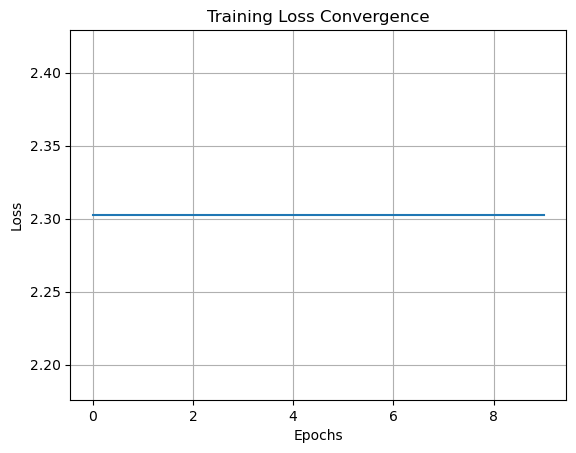

In [ ]:
learning_rate=0.01
epochs=10
loss_history=[]

for i in range(epochs):
    (z1,a1,z2,a2,z3,a3,z4,a4)=Forward_propagation(W1,b1,W2,b2,W3,b3,W4,b4,X,y)

    loss=calculate_loss(y,a4,i,m)
    loss_history.append(loss)

    (W1,b1,W2,b2,W3,b3,W4,b4)=backpropagation(W1,b1,W2,b2,W3,b3,W4,b4,z1,a1,z2,a2,z3,a3,z4,a4,X,y,learning_rate)


plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Convergence')
plt.grid(True)
plt.show()
    